# Task 1 NSW Regional statistics

## Load the csv

In [5]:
import pandas as pd

df = pd.read_csv('region_summary_NSW.csv')
df.head()

,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


## Basic Checks

In [12]:
# Information about the dataset
df.info()
df.describe(include='all').T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        800 non-null    object 
 1   Parent Description  800 non-null    object 
 2   Description         800 non-null    object 
 3   2011                259 non-null    float64
 4   2015                20 non-null     float64
 5   2016                457 non-null    float64
 6   2017                48 non-null     float64
 7   2018                125 non-null    float64
 8   2019                270 non-null    float64
 9   2020                291 non-null    float64
 10  2021                692 non-null    float64
 11  2022                293 non-null    float64
 12  2023                207 non-null    float64
 13  2024                209 non-null    float64
 14  2025                3 non-null      float64
dtypes: float64(12), object(3)
memory usage: 93.9+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Measure Code,800,800,ERP_P_20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parent Description,800,104,Estimated resident population - Females - year...,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,800,751,Employed (no.),4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,259.0,NaN,NaN,NaN,673528.398842,4126540.186104,0.1,7.95,59.9,66214.0,53566048.0
2015,20.0,NaN,NaN,NaN,8022548.67,19190682.410211,25.0,59.45,40790.5,3001437.5,80129856.0
2016,457.0,NaN,NaN,NaN,1530572.822101,7971771.441042,0.3,8.7,60.9,127179.0,80129856.0
2017,48.0,NaN,NaN,NaN,4820513.329167,14958734.123615,5.2,1094.5,14314.8,692153.5,80129856.0
2018,125.0,NaN,NaN,NaN,2249977.93984,9359767.140797,1.1,1125.0,42012.0,373693.0,80129856.0
2019,270.0,NaN,NaN,NaN,1133374.381741,6384606.435046,1.2,38.15,36056.0,255654.75,80129856.0
2020,291.0,NaN,NaN,NaN,1103432.570962,6072784.106569,1.2,52.5,36494.0,261412.5,80129856.0


In [13]:
df.isnull().sum() / len(df) * 100

Measure Code           0.000
Parent Description     0.000
Description            0.000
2011                  67.625
2015                  97.500
2016                  42.875
2017                  94.000
2018                  84.375
2019                  66.250
2020                  63.625
2021                  13.500
2022                  63.375
2023                  74.125
2024                  73.875
2025                  99.625
dtype: float64

## Cleaning steps

In [16]:
# 1) Trim columns, standardise names
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace('[^a-z0-9_]+', '_', regex=True))


# 2) Drop sparse year columns (more than 80% missing)
#    2015, 2017, 2018, 2025 are nearly empty so we remove them
year_cols = [c for c in df.columns if c.isdigit()]
sparse_cols = [c for c in year_cols if df[c].isnull().sum() / len(df) > 0.8]
df_clean = df.drop(columns=sparse_cols)
print('Dropped sparse columns:', sparse_cols)


# 3) Drop rows where ALL remaining year values are missing
good_years = [c for c in df_clean.columns if c.isdigit()]
df_clean = df_clean.dropna(subset=good_years, how='all')
print('Rows remaining after drop:', len(df_clean))


# 4) Fill remaining missing year values with column median
#    (fills gaps within years that have partial data)
df_clean[good_years] = df_clean[good_years].fillna(df_clean[good_years].median())


# 5) Strip whitespace from text columns
text_cols = ['measure_code', 'parent_description', 'description']
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()


# 6) Add a data availability flag
#    counts how many year columns have real (non-imputed) original values
original_year_counts = df[good_years].notna().sum(axis=1)
df_clean['data_points_available'] = original_year_counts.values


# 7) Save cleaned file
out_file = 'region_summary_NSW_cleaned.csv'
df_clean.to_csv(out_file, index=False)
print('Saved:', out_file)
df_clean.head()

Dropped sparse columns: ['2015', '2017', '2018', '2025']
Rows remaining after drop: 800
Saved: region_summary_NSW_cleaned.csv


,measure_code,parent_description,description,2011,2016,2019,2020,2021,2022,2023,2024,data_points_available
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),59.9,60.9,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,6
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),59.9,60.9,10.0,10.1,10.1,10.2,10.4,10.6,6
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),59.9,60.9,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,6
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),59.9,60.9,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,6
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),59.9,60.9,36.8,37.2,37.7,37.7,37.5,37.5,6


## Statistics

### Stat 1: The total number of people officially living in NSW in 2024

In [17]:
# Stat 1: Latest estimated resident population for NSW
pop_row = df[df['description'].str.contains('Estimated resident population', case=False, na=False)]
latest_pop = pop_row['2024'].dropna().values
print(f"NSW Estimated Resident Population (2024): {latest_pop}")

NSW Estimated Resident Population (2024): [8479314. 4217861. 4261453.]


### Stat 2: Unique parent categories (How many broad topic areas the dataset covers)

In [42]:
# Stat 2: How many unique parent categories exist
unique_parents = df['parent_description'].nunique()
print(f"Number of unique parent categories: {unique_parents}")
print(df['parent_description'].value_counts())

Number of unique parent categories: 104
Estimated resident population - Females - year ended 30 June               36
Estimated resident population - Persons - year ended 30 June               36
Estimated resident population - Males - year ended 30 June                 36
Personal income in Australia - year ended 30 June                          29
Commuting to work - Persons aged 15 years and older - Census               24
                                                                           ..
Land area                                                                   1
Higher Education Loan Program (HELP) - year ended 30 June                   1
Average number of children per family - Families with children - Census     1
Self-assessed health                                                        1
Private health insurance - year ended 30 June                               1
Name: parent_description, Length: 104, dtype: int64


### Stat 3: Number of metrics reported per year (How many rows have actual data for each year)

In [43]:
# Stat 3: Count of metrics available per year (non-null counts)
year_cols = ['2011','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']
metrics_per_year = df[year_cols].notna().sum()
print("Number of metrics reported per year:")
print(metrics_per_year.sort_index())


Number of metrics reported per year:
2011    259
2015     20
2016    457
2017     48
2018    125
2019    270
2020    291
2021    692
2022    293
2023    207
2024    209
2025      3
dtype: int64


### Stat 4: Year with highest average metric value

In [44]:
# Stat 4: Which year has the highest average value across all metrics
avg_by_year = df[year_cols].mean()
best_year = avg_by_year.idxmax()
print(f"Year with highest average metric value: {best_year} ({avg_by_year[best_year]:,.2f})")

Year with highest average metric value: 2015 (8,022,548.67)


### Stat 5: Coverage rate per year

Data coverage rate (%) per year:
2011    32.38
2015     2.50
2016    57.12
2017     6.00
2018    15.62
2019    33.75
2020    36.38
2021    86.50
2022    36.62
2023    25.87
2024    26.12
2025     0.38
dtype: float64


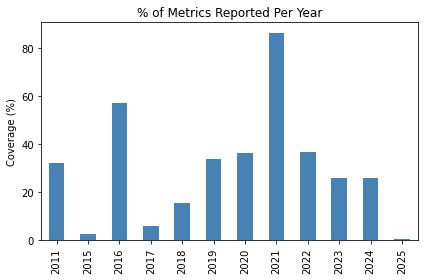

In [48]:
# Stat 5: Coverage rate — what % of metrics are reported each year
coverage = df[year_cols].notna().sum() / len(df) * 100
print("Data coverage rate (%) per year:")
print(coverage.round(2))

# Visualisation
import matplotlib.pyplot as plt
coverage.plot(kind='bar', color='steelblue', title='% of Metrics Reported Per Year')
plt.ylabel('Coverage (%)')
plt.tight_layout()
plt.savefig('coverage_rate.png')
plt.show()

### Stat 6: Metrics tracked consistently across 8+ years

In [49]:
# Stat 6: Metrics that have been consistently tracked across ALL available years
# A metric is "consistent" if it has values in at least 8 of 12 year columns
df['years_reported'] = df[year_cols].notna().sum(axis=1)
consistent_metrics = df[df['years_reported'] >= 8][['description', 'years_reported']]
print(f"Metrics tracked in 8+ years: {len(consistent_metrics)}")
print(consistent_metrics.sort_values('years_reported', ascending=False))

Metrics tracked in 8+ years: 0
Empty DataFrame
Columns: [description, years_reported]
Index: []


### Stat 7: Overall minimum and maximum ever recorded

In [50]:
# Stat 7: Minimum and maximum value ever recorded across the entire dataset
overall_min = df[year_cols].min().min()
overall_max = df[year_cols].max().max()
print(f"Overall minimum value in dataset: {overall_min}")
print(f"Overall maximum value in dataset: {overall_max}")

Overall minimum value in dataset: -39335.0
Overall maximum value in dataset: 80129856.0


### Stat 8: Median value per year

In [27]:
# Stat 9: Median value per year (more robust than mean given wide value range)
median_by_year = df[year_cols].median()
print("Median metric value per year:")
print(median_by_year)

Median metric value per year:
2011       59.90
2015    40790.50
2016       60.90
2017    14314.80
2018    42012.00
2019    36056.00
2020    36494.00
2021     2956.45
2022    41032.00
2023    37466.00
2024    31827.00
2025     6094.00
dtype: float64


### Stat 9: Metrics that only appear in one year

In [51]:
# Stat 9: Number of metrics that only appear once (single year reporting)
single_year = df[df['years_reported'] == 1]
print(f"Metrics reported in only one year: {len(single_year)}")
print(single_year[['description', 'parent_description']])

Metrics reported in only one year: 105
                                           description  \
156  Currently serving in the Australian Defence Fo...   
157  Previously served in the Australian Defence Fo...   
158  Currently serving in the Australian Defence Fo...   
159  Previously served in the Australian Defence Fo...   
217     Profound/severe core activity limitation (no.)   
..                                                 ...   
795                    Multiple-use public forest (ha)   
796                          Other Crown purposes (ha)   
797                              Other Crown land (ha)   
798                    Land tenure not classified (ha)   
799                             Total land tenure (ha)   

                                    parent_description  
156  Australian Defence Force service - Persons age...  
157  Australian Defence Force service - Persons age...  
158  Australian Defence Force service - Persons age...  
159  Australian Defence Force servic

### Stat 10: Year-over-year growth/decline 2021 to 2022

In [52]:
# Stat 10: Year-over-year change for each metric between 2021 and 2022
# (most complete consecutive year pair)
df['change_2021_to_2022'] = df['2022'] - df['2021']
df['pct_change_2021_to_2022'] = (df['change_2021_to_2022'] / df['2021']) * 100

# Top 5 metrics that grew the most
top_growth = df[['description', 'change_2021_to_2022', 'pct_change_2021_to_2022']]\
    .dropna().nlargest(5, 'pct_change_2021_to_2022')
print("Top 5 fastest growing metrics 2021→2022:")
print(top_growth)

# Top 5 metrics that declined the most
top_decline = df[['description', 'change_2021_to_2022', 'pct_change_2021_to_2022']]\
    .dropna().nsmallest(5, 'pct_change_2021_to_2022')
print("\nTop 5 biggest declining metrics 2021→2022:")
print(top_decline)

Top 5 fastest growing metrics 2021→2022:
                                           description  change_2021_to_2022  \
123                       Net internal migration (no.)             -22513.0   
124                            Overseas arrivals (no.)              80106.0   
278  Number of employing business exits: 1-4 employees               8345.0   
312  Number of business entries with turnover of $5...                151.0   
313  Number of business entries with turnover of $1...                126.0   

     pct_change_2021_to_2022  
123               133.830698  
124               110.097720  
278                51.719864  
312                51.535836  
313                41.311475  

Top 5 biggest declining metrics 2021→2022:
                                       description  change_2021_to_2022  \
126                   Net overseas migration (no.)              75052.0   
386                    Apartments - removals (no.)               -132.0   
385                   Apartme

### Stat 11: Which year had the most variability

In [53]:
# Stat 11: Standard deviation per year — which year had most variability?
std_by_year = df[year_cols].std()
most_variable_year = std_by_year.idxmax()
print(f"Year with highest variability: {most_variable_year} (std={std_by_year[most_variable_year]:,.2f})")
print(std_by_year)

Year with highest variability: 2015 (std=19,190,682.41)
2011    4.126540e+06
2015    1.919068e+07
2016    7.971771e+06
2017    1.495873e+07
2018    9.359767e+06
2019    6.384606e+06
2020    6.072784e+06
2021    4.611798e+06
2022    1.148907e+06
2023    8.011850e+05
2024    1.048662e+06
2025    8.775542e+03
dtype: float64


### Stat 12: Percentage-based vs absolute count metrics

In [54]:
# Stat 12: How many metrics are percentage-based vs absolute counts
# (infer from description text)
pct_metrics = df[df['description'].str.contains('%|percent|rate|ratio', case=False, na=False)]
abs_metrics = df[~df['description'].str.contains('%|percent|rate|ratio', case=False, na=False)]
print(f"Percentage/rate metrics: {len(pct_metrics)}")
print(f"Absolute count metrics: {len(abs_metrics)}")

Percentage/rate metrics: 321
Absolute count metrics: 479


### Stat 13: Top 5 highest-value metrics in 2021

In [55]:
# Stat 13: Top 5 metrics with highest 2021 value
top5_2021 = df.nlargest(5, '2021')[['description', 'parent_description', '2021']]
print("Top 5 highest-value metrics in 2021:")
print(top5_2021)

Top 5 highest-value metrics in 2021:
                           description  \
737                     Land area (ha)   
738     Area of agricultural land (ha)   
346  Area of holding - total area (ha)   
351        Meat chickens - total (no.)   
349      Sheep and lambs - total (no.)   

                                    parent_description        2021  
737                                          Land area  80079765.9  
738  Water use on Australian farms - year ended 30 ...  53822774.0  
346      Agricultural commodities - year ended 30 June  53822773.8  
351      Agricultural commodities - year ended 30 June  39149834.9  
349      Agricultural commodities - year ended 30 June  24711533.7  


### Stat 14: Coefficient of Variation — most volatile metrics

In [56]:
# Stat 14: Coefficient of variation (CV) per metric across years
# CV = std/mean — measures relative variability, 
# high CV means the metric fluctuates a lot year to year
df['cv_across_years'] = df[year_cols].std(axis=1) / df[year_cols].mean(axis=1).abs()

most_volatile = df[['description', 'cv_across_years']].dropna()\
    .sort_values('cv_across_years', ascending=False).head(10)
print("Most volatile metrics (high year-to-year fluctuation):")
print(most_volatile)

most_stable = df[['description', 'cv_across_years']].dropna()\
    .sort_values('cv_across_years').head(10)
print("\nMost stable metrics over time:")
print(most_stable)

Most volatile metrics (high year-to-year fluctuation):
                                           description  cv_across_years
786                     Land cover not classified (ha)         1.405452
572  Persons who cared for own child/children and o...         1.245053
632                             Worked from home (no.)         1.182767
784                          Water: non-perennial (ha)         0.969829
487  Working (away from work) and studying full-tim...         0.877642
126                       Net overseas migration (no.)         0.851596
573                   Unpaid child care not stated (%)         0.789057
781         Natural aquatic vegetated: herbaceous (ha)         0.788194
745               All other protected land areas (no.)         0.774211
383                        Townhouses - removals (no.)         0.706550

Most stable metrics over time:
                                           description  cv_across_years
787                              Total land cover

### Stat 15: Year-to-year correlation heatmap

Correlation between 2021 and 2022 values: 0.9995


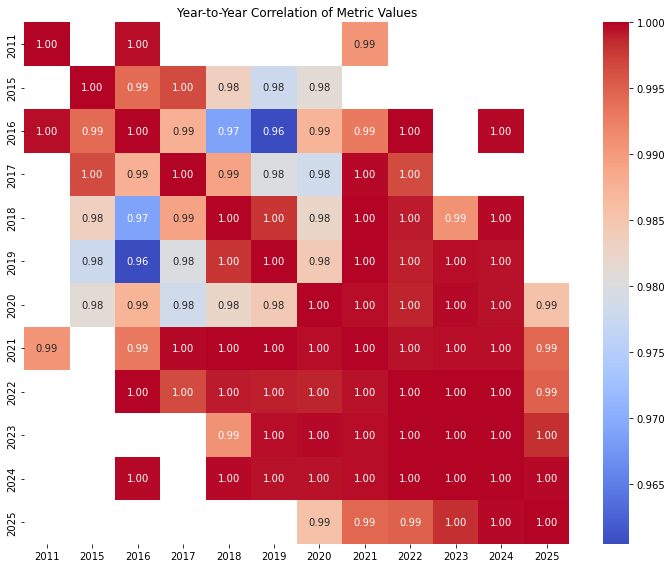

In [58]:
# Stat 15: Correlation between 2021 and 2022 values across all metrics
# High correlation = metrics that were high in 2021 stayed high in 2022
corr_2021_2022 = df[['2021','2022']].corr().iloc[0,1]
print(f"Correlation between 2021 and 2022 values: {corr_2021_2022:.4f}")
corr_matrix = df[year_cols].corr()
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Year-to-Year Correlation of Metric Values')
plt.tight_layout()
plt.savefig('year_correlation.png')
plt.show()

### Stat 16: Number of metrics per parent category

In [59]:
# Stat 16: How many metrics fall under each parent description
metrics_per_category = df.groupby('parent_description')['measure_code'].count()\
    .sort_values(ascending=False)
print("Number of metrics per parent category:")
print(metrics_per_category)

Number of metrics per parent category:
parent_description
Estimated resident population - Females - year ended 30 June               36
Estimated resident population - Males - year ended 30 June                 36
Estimated resident population - Persons - year ended 30 June               36
Personal income in Australia - year ended 30 June                          29
Commuting to work - Persons aged 15 years and older - Census               24
                                                                           ..
Higher Education Loan Program (HELP) - year ended 30 June                   1
Private health insurance - year ended 30 June                               1
Average number of children per family - Families with children - Census     1
Land area                                                                   1
Self-assessed health                                                        1
Name: measure_code, Length: 104, dtype: int64


### Stat 17: Most recent year of data per category

In [60]:
# Stat 17: For each parent category, what is the most recent year with data?
def most_recent_year(row):
    for year in ['2025','2024','2023','2022','2021','2020','2019','2018','2017','2016','2015','2011']:
        if pd.notna(row[year]):
            return year
    return None

df['most_recent_year'] = df.apply(most_recent_year, axis=1)
print("Most recent year of data per category:")
print(df.groupby('parent_description')['most_recent_year'].agg(lambda x: x.mode()[0]))


Most recent year of data per category:
parent_description
Aboriginal and Torres Strait Islander Peoples - Census                        2021
Age of persons born overseas - Census                                         2021
Agricultural commodities - year ended 30 June                                 2021
Australian Defence Force service - Persons aged 15 years and over - Census    2021
Australian citizenship - Census                                               2021
                                                                              ... 
Usual and preferred health service providers                                  2019
Voluntary work for an organisation or group - Census                          2021
Water use on Australian farms - year ended 30 June                            2021
Year of arrival of persons born overseas - Census                             2021
Youth engagement in work/study - Persons aged 15-19 years - Census            2021
Name: most_recent_year, Lengt

### Stat 18: Percentage of metrics that increased from 2020 to 2021

In [61]:
# Stat 18: What percentage of metrics saw an increase from 2020 to 2021 (COVID recovery signal)?
df['recovered_post_covid'] = df['2021'] > df['2020']
recovery_pct = df['recovered_post_covid'].dropna().mean() * 100
print(f"percentage of metrics that increased from 2020 to 2021: {recovery_pct:.1f}%")

percentage of metrics that increased from 2020 to 2021: 19.5%


### Stat 19: Which metric had the biggest single jump between any two consecutive years

In [62]:
# Stat 19: Calculate the biggest jump between consecutive years for each metric
consecutive_pairs = [('2019','2020'), ('2020','2021'), ('2021','2022'), ('2022','2023'), ('2023','2024')]

for y1, y2 in consecutive_pairs:
    df[f'jump_{y1}_{y2}'] = abs(df[y2] - df[y1])

jump_cols = [f'jump_{y1}_{y2}' for y1, y2 in consecutive_pairs]
df['biggest_jump'] = df[jump_cols].max(axis=1)
df['biggest_jump_period'] = df[jump_cols].idxmax(axis=1)

top5 = df.nlargest(5, 'biggest_jump')[['description', 'biggest_jump', 'biggest_jump_period']]
print("Top 5 metrics with the biggest single jump between consecutive years:")
print(top5)

Top 5 metrics with the biggest single jump between consecutive years:
                                           description  biggest_jump  \
777  Cultivated terrestrial vegetated: herbaceous (ha)    11396694.0   
780                              Natural surfaces (ha)    10313232.0   
778     Natural terrestrial vegetated: herbaceous (ha)     7571662.0   
779          Natural terrestrial vegetated: woody (ha)     6322063.0   
738                     Area of agricultural land (ha)     2542984.0   

    biggest_jump_period  
777      jump_2019_2020  
780      jump_2019_2020  
778      jump_2019_2020  
779      jump_2019_2020  
738      jump_2020_2021  


### Stat 20:Metrics that have never had a zero or negative value

In [63]:
# Stat 20: Find metrics that have always been positive across all years
always_positive = df[(df[year_cols] > 0).all(axis=1)]

print(f"Metrics that have always been positive: {len(always_positive)}")
print(always_positive[['description', 'parent_description']])

Metrics that have always been positive: 0
Empty DataFrame
Columns: [description, parent_description]
Index: []
